<div style="background-color: #013a63; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    CSCA 5642 - Introduction to Deep Learning - Final Project
</div>

<div style="background-color: magenta; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Stock Market Price Pridiction and Direction Prediction
</div>

#### Project Overview: Stock Market Prediction using Deep Learning

This project aims to predict stock market price movements using deep learning techniques. We will explore both price value prediction and directional movement prediction (up or down).

Here is a breakdown of the steps involved:

**1. Data Collection:**
*   **Source:** We will fetch historical stock data using the Alpaca API.
*   **Features:** The dataset will include Open, High, Low, Close prices, and Volume (OHLCV).
*   **Target:** We will select a specific stock or index to focus on, for example, SPY (S&P 500 ETF) or a major tech stock like AAPL.

**2. Data Preprocessing and Feature Engineering:**
*   **Data Cleaning:** Handle any missing values in the dataset.
*   **Feature Scaling:** Normalize the data, particularly the price and volume, to a range (e.g., 0 to 1) using `MinMaxScaler`. This is crucial for neural network performance.
*   **Technical Indicators:** Engineer new features by calculating technical indicators. These can provide valuable signals for the model. Examples include:
    *   Moving Averages (SMA, EMA)
    *   Relative Strength Index (RSI)
    *   Moving Average Convergence Divergence (MACD)
*   **Sequence Creation:** Transform the time-series data into sequences of a fixed length (e.g., use the last 60 days of data to predict the next day).

**3. Model Selection:**
For time-series forecasting, Recurrent Neural Networks (RNNs) are a strong choice.
*   **LSTM (Long Short-Term Memory):** This is an excellent starting point. LSTMs are designed to remember long-term dependencies, which is perfect for financial time-series data.
*   **GRU (Gated Recurrent Unit):** A variation of LSTM, which is slightly simpler and can be faster to train. It's worth experimenting with as it can sometimes yield better results on certain datasets.
*   **Hybrid Models (e.g., CNN-LSTM):** A Convolutional Neural Network (CNN) can be used to extract features from the input sequences before feeding them into an LSTM. This can sometimes improve performance.

We will start with an LSTM model.

**4. Model Training:**
*   **Data Splitting:** Split the data chronologically into training, validation, and testing sets. A common split is 80% for training, 10% for validation, and 10% for testing.
*   **Model Architecture:** Define the layers of the LSTM network (e.g., number of LSTM layers, number of neurons, dropout layers for regularization).
*   **Compilation:**
    *   **Loss Function:** For price prediction, we'll use a regression loss like `Mean Squared Error (MSE)`. For direction prediction, we'll use `Binary Cross-Entropy`.
    *   **Optimizer:** `Adam` is generally a good choice.
*   **Training:** Train the model on the training data while monitoring its performance on the validation data to prevent overfitting.

**5. Model Evaluation:**
*   **Price Prediction Metrics:** Evaluate the model on the test set using metrics like:
    *   Root Mean Squared Error (RMSE)
    *   Mean Absolute Error (MAE)
*   **Direction Prediction Metrics:**
    *   Accuracy
    *   Precision, Recall, F1-Score
    *   Confusion Matrix
*   **Visualization:** Plot the predicted prices against the actual prices to visually inspect the model's performance.

**6. Conclusion and Future Work:**
*   Summarize the results and the performance of the model.
*   Discuss potential improvements, such as:
    *   Hyperparameter tuning.
    *   Trying different model architectures.
    *   Incorporating sentiment analysis from financial news.
    *   Applying the model to other stocks or markets.


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Dataset Description - Alpaca Datafeed
</div>

Alpaca is a modern platform for algorithmic trading that provides a powerful API for accessing real-time and historical market data. The Alpaca Data API is a key component for developers and traders who need reliable and fast access to stock market data.

### Key Features of Alpaca's Datafeed:

*   **Broad Coverage:** Alpaca provides data for a wide range of U.S. equities. You can access data for major stocks like **NVIDIA (NVDA)**, a leading technology company known for its GPUs, as well as Exchange-Traded Funds (ETFs) like **SPY**, which tracks the S&P 500 index.
*   **Real-Time and Historical Data:** You can get up-to-the-minute data for active trading or fetch historical data going back several years for backtesting and analysis.
*   **Data Format (OHLCV):** The data is typically provided in the standard OHLCV format:
    *   **Open:** The price at the beginning of the time interval.
    *   **High:** The highest price during the interval.
    *   **Low:** The lowest price during the interval.
    *   **Close:** The price at the end of the time interval.
    *   **Volume:** The number of shares traded during the interval.
*   **Flexible Timeframes:** The API allows you to specify the timeframe for the data bars, such as:
    *   `1Min` for minute-level data.
    *   `1Day` for daily data.
    *   `1Week` for weekly data.
*   **Easy Integration:** The data can be easily integrated into Python applications using the `alpaca-trade-api` library, which returns data in a pandas DataFrame, making it convenient for data analysis and machine learning.

### Example: SPY vs. NVDA

*   **SPY (SPDR S&P 500 ETF Trust):** This is one of the largest and most popular ETFs. It is designed to track the performance of the S&P 500, which is a stock market index that represents the performance of 500 of the largest companies listed on stock exchanges in the United States.
*   **NVDA (NVIDIA Corporation):** This is a major technology company, a leader in the design of graphics processing units (GPUs). As a single stock, its price is more volatile and influenced by company-specific news and performance, in addition to broader market trends.

Using Alpaca, we can fetch and compare the historical performance of a broad market index (SPY) and a specific, high-growth stock (NVDA) to analyze different market behaviors.

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Install Dependencies
</div>

In [139]:
!pip install alpaca-trade-api python-dotenv pandas numpy matplotlib scikit-learn tensorflow pandas_ta alpaca-py requests

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Libraries
</div>

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

import alpaca_trade_api as tradeapi
import pandas as pd
import os
from dotenv import load_dotenv


import sys

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
import datetime

# Load environment variables from .env file
load_dotenv()


#import pandas_ta as ta

True

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Mount Google Drive for Colab - Optional and only if using Colab
</div>

In [141]:
from google.colab import drive
drive.mount('/content/drive/')

ModuleNotFoundError: No module named 'google.colab'

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Loading the Dataset
</div>

In [ ]:
API_KEY = os.getenv("ALPACA_API_ID_KEY")
SECRET_KEY = os.getenv("ALPACA_API_SECRET_KEY")
BASE_URL = "https://paper-api.alpaca.markets"  # Use paper trading URL for development


API_KEY = "PKV6S69U0DRCF39RWQBY"
SECRET_KEY = "iVDBmzj4sn3kn3azwy2e3HPccJ3qBbHtNhsvH55Q"

# Set the stock symbol and prediction parameters
SYMBOL = "SPY"
timeframe = "daily"
interval = 1
#timeframe = "minute"
#interval = 5
start_date = '2003-01-01'
#end_date = '2023-01-05'
end_date = '2025-09-12'
LOOK_BACK_DAYS = 90  # Number of past days to use for prediction
PREDICTION_DAYS = 30 # Not used in this version, but kept for context.
LSTM_UNITS = 50      # Number of units in the LSTM layer
EPOCHS = 20          # Number of training epochs
BATCH_SIZE = 32      # Batch size for training

2. Data Fetching

In [ ]:
def fetch_data(symbol: str, timeframe: str = "daily", interval: int = 1, bars_back: int = 200, start_date: str = None, end_date: str = None):
    """
    Fetches historical stock data using the Alpaca API.
    Note: This SDK is deprecated and no longer maintained.
    """
    print(f"Fetching data for {symbol}...")
    try:
        # --- Initialize the Alpaca API ---
        api = tradeapi.REST(API_KEY, SECRET_KEY, base_url=BASE_URL, api_version='v2')

        # --- Parameters for Data Fetching ---
        if timeframe == "daily":
            bars = api.get_bars(symbol, tradeapi.TimeFrame.Day, start=start_date, end=end_date).df
        elif timeframe == "minute":
            bars = api.get_bars(symbol, tradeapi.TimeFrame(amount=interval, unit=tradeapi.TimeFrameUnit.Minute), start=start_date, end=end_date).df
        else:
            raise ValueError("Invalid timeframe. Use 'daily' or 'minute'.")

        # The .df property returns the data as a pandas DataFrame
        print(f"Successfully fetched {len(bars)} data points for {symbol}.")
        print("First 5 rows of the dataset:")
        print(bars.head())

        return bars

    except Exception as e:
        print(f"Error fetching data from Alpaca: {e}")
        return None

3. Feature Engineering

In [ ]:
def create_features(df):
    """
    Creates several technical indicator features from the raw OHLCV data.

    FEATURES:

        open
        high
        low
        close
        volume
        number_of_trades
        bar_ts
        trade_date
        trade_time
        vwap
        momentum_5
        momentum_10
        stddev_10
        relative_volume_30
        minutes_since_open
        bar_num
        high_since_open
        low_since_open
        cumulative_volume
        open_at_930am
        close_at_4pm
        SMA_6
        SMA_20
        RSI
        MACD_6_20_9 (+ signal & hist)
        Bollinger_High
        Bollinger_Low
        Volume_SMA_5

    """
    print("Creating technical indicator features...")
    df = df.copy()

    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df['trade_date'] = df.index.date
    df['trade_time'] = df.index.time

    # Momentum and rolling stats
    df['momentum_5'] = df['close'] - df['close'].shift(5)
    df['momentum_10'] = df['close'] - df['close'].shift(10)
    df['stddev_10'] = df['close'].rolling(window=10).std()

    # Relative volume
    df['relative_volume_30'] = df['volume'] / df['volume'].rolling(window=30).mean()

    # Minutes since market open (approx); produces negative values for pre-market
    #def _minutes_since_open(ts):
    #    return ts.hour * 60 + ts.minute - (9 * 60 + 30)
    #df['minutes_since_open'] = df.index.map(_minutes_since_open)

    def _minutes_since_open(ts):
        # Market open at 09:30 (9*60+30) and close at 16:00 (16*60)
        open_min = 9 * 60 + 30
        close_min = 16 * 60
        minutes = ts.hour * 60 + ts.minute
        # If before open or at/after close, mark as -1
        if minutes < open_min or minutes > close_min:
            return -1
        return minutes - open_min
    df['minutes_since_open'] = df.index.map(_minutes_since_open)


    # Per-day aggregations
    df['bar_num'] = df.groupby('trade_date').cumcount() + 1
    df['high_since_open'] = df.groupby('trade_date')['high'].cummax()
    df['low_since_open'] = df.groupby('trade_date')['low'].cummin()
    df['cumulative_volume'] = df.groupby('trade_date')['volume'].cumsum()
    
    # Prefer the first regular-market bar (minutes_since_open >= 0) as the market open
    # and the last regular-market bar as the market close for each trade_date.
    # This avoids picking pre-/post-market first/last rows.
    opens = df[df['minutes_since_open'] >= 0].groupby('trade_date')['open'].first()
    closes = df[df['minutes_since_open'] >= 0].groupby('trade_date')['close'].last()
    df['open_at_930am'] = df['trade_date'].map(opens)
    df['close_at_4pm'] = df['trade_date'].map(closes)

    # Moving averages
    df['SMA_6'] = df['close'].rolling(window=6).mean()
    df['SMA_20'] = df['close'].rolling(window=20).mean()  # FIX: add parentheses to compute mean

    # RSI (standard calculation)
    delta = df['close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD (6,20) with 9-period signal and histogram
    exp_fast = df['close'].ewm(span=6, adjust=False).mean()
    exp_slow = df['close'].ewm(span=20, adjust=False).mean()
    macd = exp_fast - exp_slow
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    df['MACD_6_20_9'] = macd
    df['MACD_SIGNAL_6_20_9'] = macd_signal
    df['MACD_HIST_6_20_9'] = macd - macd_signal

    # Bollinger Bands (based on SMA_20)
    rolling_std_20 = df['close'].rolling(window=20).std()
    df['Bollinger_High'] = df['SMA_20'] + (2 * rolling_std_20)
    df['Bollinger_Low'] = df['SMA_20'] - (2 * rolling_std_20)

    # Volume SMA
    df['Volume_SMA_5'] = df['volume'].rolling(window=5).mean()

    # Drop initial NaNs produced by rolling calculations
    df.fillna(0, inplace=True)
    #df.dropna(inplace=True)

    print(f"Features created. Shape of data: {df.shape}")
    return df

4. Data Loading

Fetching data for SPY...
Successfully fetched 2438 data points for SPY.
First 5 rows of the dataset:
                              close    high     low  trade_count     open  \
timestamp                                                                   
2016-01-04 05:00:00+00:00  201.0192  201.03  198.59       655489  200.490   
2016-01-05 05:00:00+00:00  201.3600  201.90  200.05       418709  201.405   
2016-01-06 05:00:00+00:00  198.8200  200.06  197.60       548386  198.330   
2016-01-07 05:00:00+00:00  194.0500  197.44  193.59       796451  195.330   
2016-01-08 05:00:00+00:00  191.9230  195.85  191.58       754102  195.190   

                              volume        vwap  
timestamp                                         
2016-01-04 05:00:00+00:00  225903783  199.753436  
2016-01-05 05:00:00+00:00  112719152  201.085380  
2016-01-06 05:00:00+00:00  153948196  198.839872  
2016-01-07 05:00:00+00:00  216191953  195.202134  
2016-01-08 05:00:00+00:00  216105404  193.673322  
Cr

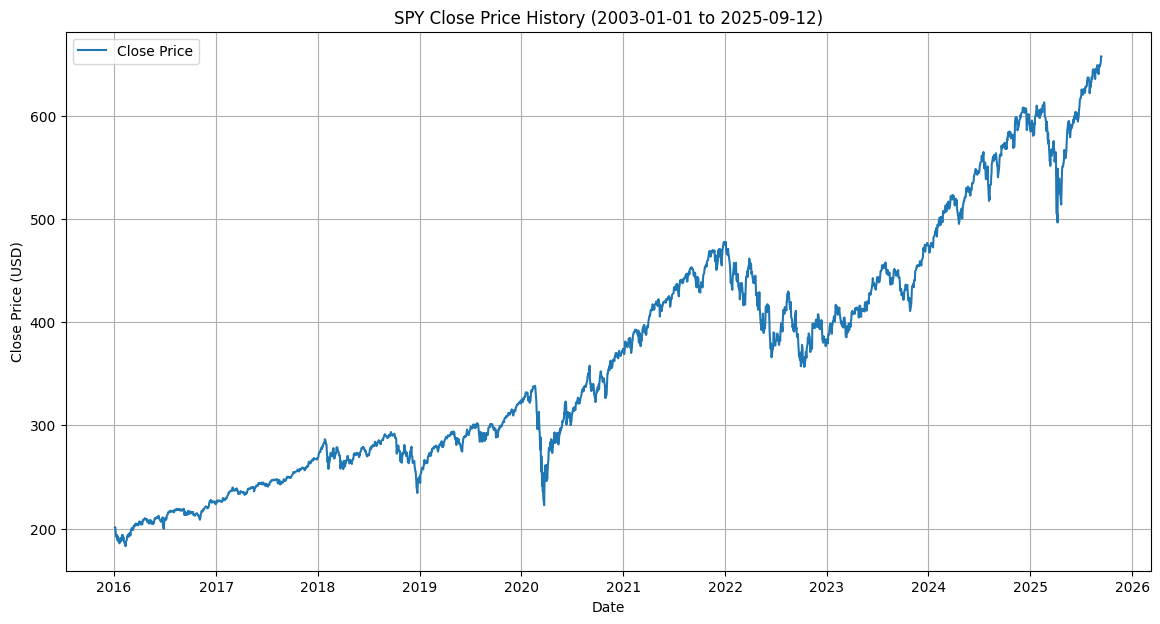

In [ ]:
# --- Fetch the Data ---
try:

    stock_data = fetch_data(symbol=SYMBOL, timeframe=timeframe, interval=interval, bars_back=200, start_date=start_date, end_date=end_date)
    stock_data = create_features(stock_data)

    # The .df property returns the data as a pandas DataFrame
    print(f"Successfully fetched {len(stock_data)} data points for {SYMBOL}.")
    print("First 5 rows of the dataset:")
    print(stock_data.head())

    # --- Inspect the Data ---
    print("\nDataset Info:")
    stock_data.info()

    print("\nDataset Description:")
    print(stock_data.describe())

    # --- Plot the Closing Price ---
    plt.figure(figsize=(14, 7))
    plt.plot(stock_data['close'], label='Close Price')
    plt.title(f'{SYMBOL} Close Price History ({start_date} to {end_date})')
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"An error occurred while fetching data: {e}")
    print("Please ensure your API keys are correct and have the necessary permissions.")


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Save the Data to a CSV file
</div>

In [ ]:
# --- Save the Data to a CSV file ---

if 'stock_data' in locals() and not stock_data.empty:
    csv_file_path = f'{SYMBOL}_stock_data_{interval}{timeframe}_{start_date}_to_{end_date}.csv'
    stock_data.to_csv(csv_file_path)
    print(f"\nData saved to {csv_file_path}")


Data saved to SPY_stock_data_1daily_2003-01-01_to_2025-09-12.csv


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Load Data from CSV file
</div>

In [ ]:
# Load stock_data from a CSV file (update path if necessary)
csv_file_path = './SPY_stock_data_1daily_2003-01-01_to_2025-09-12.csv'  # <-- change if your file is elsewhere

# Read CSV
stock_data = pd.read_csv(csv_file_path)

# If there's a 'timestamp' column, use it as the DatetimeIndex
if 'timestamp' in stock_data.columns:
    stock_data['timestamp'] = pd.to_datetime(stock_data['timestamp'], errors='coerce')
    stock_data.set_index('timestamp', inplace=True)
# Handle common unnamed index written by to_csv
elif 'Unnamed: 0' in stock_data.columns:
    try:
        stock_data['Unnamed: 0'] = pd.to_datetime(stock_data['Unnamed: 0'], errors='coerce')
        stock_data.set_index('Unnamed: 0', inplace=True)
    except Exception:
        pass
else:
    # Try to convert the existing index to datetime if possible
    try:
        stock_data.index = pd.to_datetime(stock_data.index, errors='coerce')
    except Exception:
        pass

# Quick checks
print(f"Loaded '{csv_file_path}' -> shape: {stock_data.shape}")
print("Index dtype:", stock_data.index.dtype)
stock_data.head()

Loaded './SPY_stock_data_1daily_2003-01-01_to_2025-09-12.csv' -> shape: (2438, 29)
Index dtype: datetime64[ns, UTC]


,close,high,low,trade_count,open,volume,vwap,trade_date,trade_time,momentum_5,...,close_at_4pm,SMA_6,SMA_20,RSI,MACD_6_20_9,MACD_SIGNAL_6_20_9,MACD_HIST_6_20_9,Bollinger_High,Bollinger_Low,Volume_SMA_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-04 05:00:00+00:00,201.0192,201.03,198.59,655489,200.490,225903783,199.753436,2016-01-04,05:00:00,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2016-01-05 05:00:00+00:00,201.3600,201.90,200.05,418709,201.405,112719152,201.085380,2016-01-05,05:00:00,0.0,...,0.0,0.0,0.0,0.0,0.064914,0.012983,0.051931,0.0,0.0,0.0
2016-01-06 05:00:00+00:00,198.8200,200.06,197.60,548386,198.330,153948196,198.839872,2016-01-06,05:00:00,0.0,...,0.0,0.0,0.0,0.0,-0.378710,-0.065356,-0.313354,0.0,0.0,0.0
2016-01-07 05:00:00+00:00,194.0500,197.44,193.59,796451,195.330,216191953,195.202134,2016-01-07,05:00:00,0.0,...,0.0,0.0,0.0,0.0,-1.563673,-0.365019,-1.198654,0.0,0.0,0.0
2016-01-08 05:00:00+00:00,191.9230,195.85,191.58,754102,195.190,216105404,193.673322,2016-01-08,05:00:00,0.0,...,0.0,0.0,0.0,0.0,-2.692059,-0.830427,-1.861632,0.0,0.0,184973697.6


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Exploratory Data Analysis
</div>

In [ ]:
stock_data.head()

,close,high,low,trade_count,open,volume,vwap,trade_date,trade_time,momentum_5,...,close_at_4pm,SMA_6,SMA_20,RSI,MACD_6_20_9,MACD_SIGNAL_6_20_9,MACD_HIST_6_20_9,Bollinger_High,Bollinger_Low,Volume_SMA_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-04 05:00:00+00:00,201.0192,201.03,198.59,655489,200.490,225903783,199.753436,2016-01-04,05:00:00,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2016-01-05 05:00:00+00:00,201.3600,201.90,200.05,418709,201.405,112719152,201.085380,2016-01-05,05:00:00,0.0,...,0.0,0.0,0.0,0.0,0.064914,0.012983,0.051931,0.0,0.0,0.0
2016-01-06 05:00:00+00:00,198.8200,200.06,197.60,548386,198.330,153948196,198.839872,2016-01-06,05:00:00,0.0,...,0.0,0.0,0.0,0.0,-0.378710,-0.065356,-0.313354,0.0,0.0,0.0
2016-01-07 05:00:00+00:00,194.0500,197.44,193.59,796451,195.330,216191953,195.202134,2016-01-07,05:00:00,0.0,...,0.0,0.0,0.0,0.0,-1.563673,-0.365019,-1.198654,0.0,0.0,0.0
2016-01-08 05:00:00+00:00,191.9230,195.85,191.58,754102,195.190,216105404,193.673322,2016-01-08,05:00:00,0.0,...,0.0,0.0,0.0,0.0,-2.692059,-0.830427,-1.861632,0.0,0.0,184973697.6


In [ ]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2438 entries, 2016-01-04 05:00:00+00:00 to 2025-09-12 04:00:00+00:00
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   close               2438 non-null   float64
 1   high                2438 non-null   float64
 2   low                 2438 non-null   float64
 3   trade_count         2438 non-null   int64  
 4   open                2438 non-null   float64
 5   volume              2438 non-null   int64  
 6   vwap                2438 non-null   float64
 7   trade_date          2438 non-null   object 
 8   trade_time          2438 non-null   object 
 9   momentum_5          2438 non-null   float64
 10  momentum_10         2438 non-null   float64
 11  stddev_10           2438 non-null   float64
 12  relative_volume_30  2438 non-null   float64
 13  minutes_since_open  2438 non-null   int64  
 14  bar_num             2438 non-null   int64  
 15  high_si

In [ ]:
print(stock_data.describe())

             close         high          low   trade_count         open  \
count  2438.000000  2438.000000  2438.000000  2.438000e+03  2438.000000   
mean    367.019087   368.957505   364.747599  4.844918e+05   366.937511   
std     119.343147   119.883232   118.659206  3.243454e+05   119.312674   
min     182.860000   184.100000   181.020000  8.430700e+04   182.340000   
25%     269.520000   271.205000   267.325000  2.804525e+05   268.802500   
50%     351.465000   353.365000   349.060000  4.194725e+05   350.550000   
75%     444.137500   446.415000   442.420000  5.952338e+05   444.085000   
max     657.630000   659.110000   656.900000  3.709929e+06   657.600000   

             volume         vwap   momentum_5  momentum_10    stddev_10  ...  \
count  2.438000e+03  2438.000000  2438.000000  2438.000000  2438.000000  ...   
mean   8.389997e+07   366.930293     0.934880     1.866414     4.251594  ...   
std    4.187458e+07   119.296075     8.805633    12.110425     3.297532  ...   
min 

Shape: (2438, 29)

Missing values per column:
 close                 0
high                  0
low                   0
trade_count           0
open                  0
volume                0
vwap                  0
trade_date            0
trade_time            0
momentum_5            0
momentum_10           0
stddev_10             0
relative_volume_30    0
minutes_since_open    0
bar_num               0
high_since_open       0
low_since_open        0
cumulative_volume     0
open_at_930am         0
close_at_4pm          0
SMA_6                 0
SMA_20                0
RSI                   0
MACD_6_20_9           0
MACD_SIGNAL_6_20_9    0
MACD_HIST_6_20_9      0
Bollinger_High        0
Bollinger_Low         0
Volume_SMA_5          0
dtype: int64

Descriptive statistics (selected columns):
              close        volume        SMA_6       SMA_20          RSI
count  2438.000000  2.438000e+03  2438.000000  2438.000000  2438.000000
mean    367.019087  8.389997e+07   366.143320   363.737

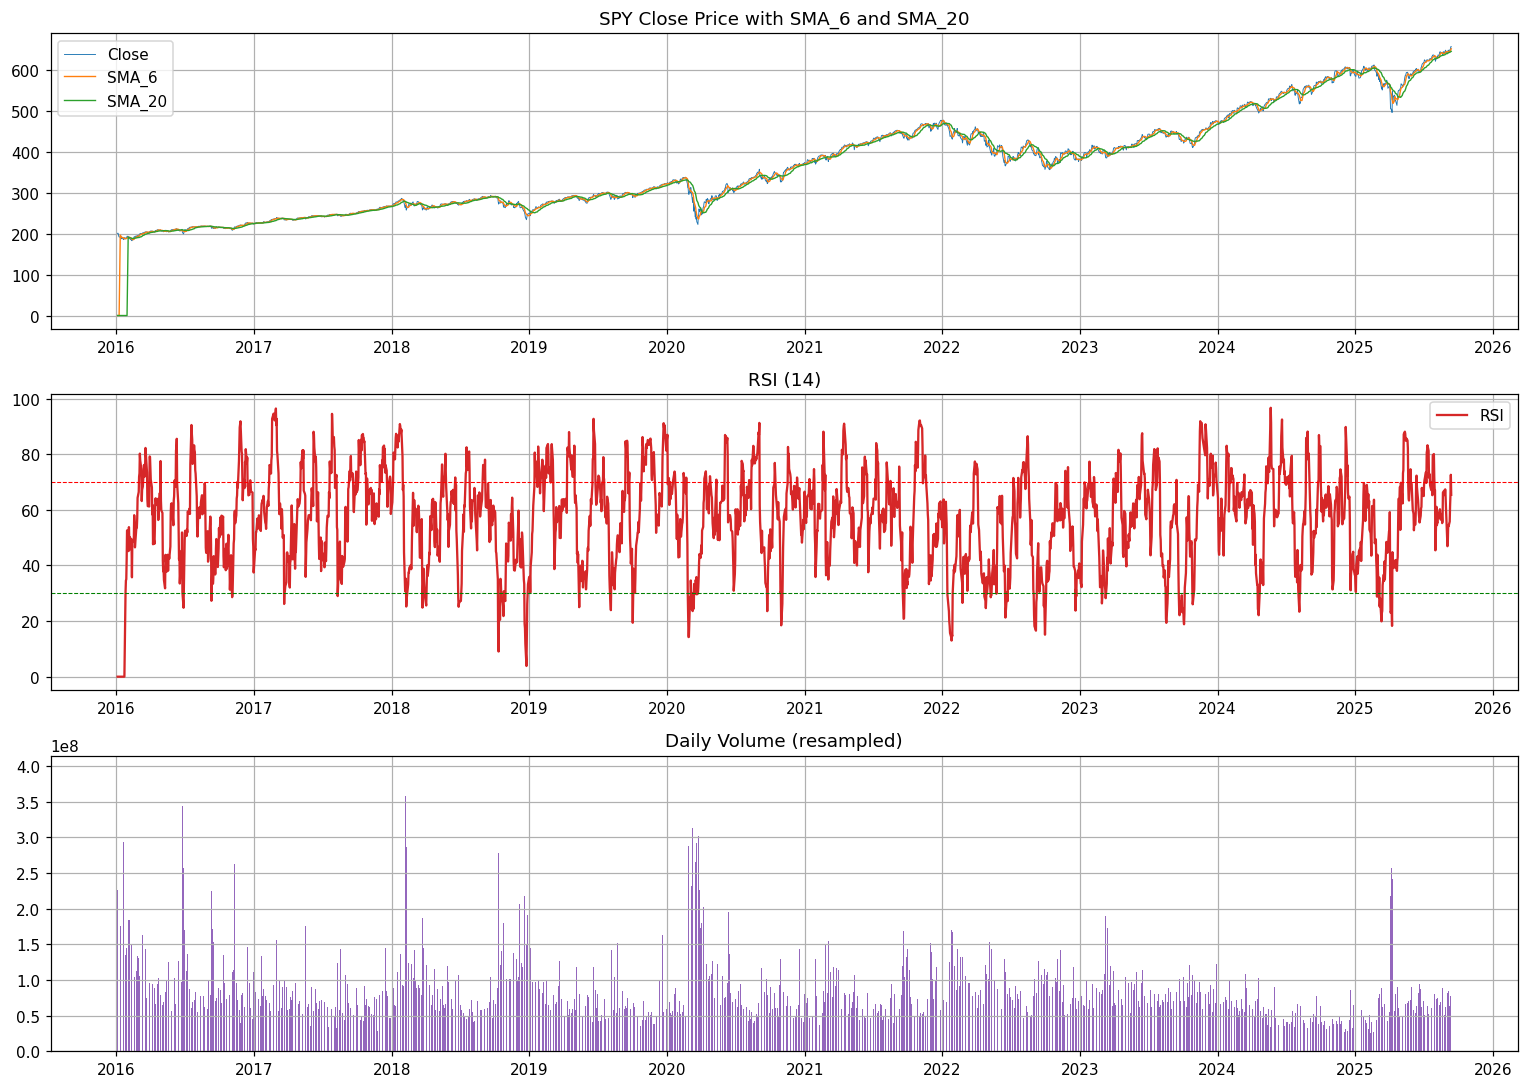

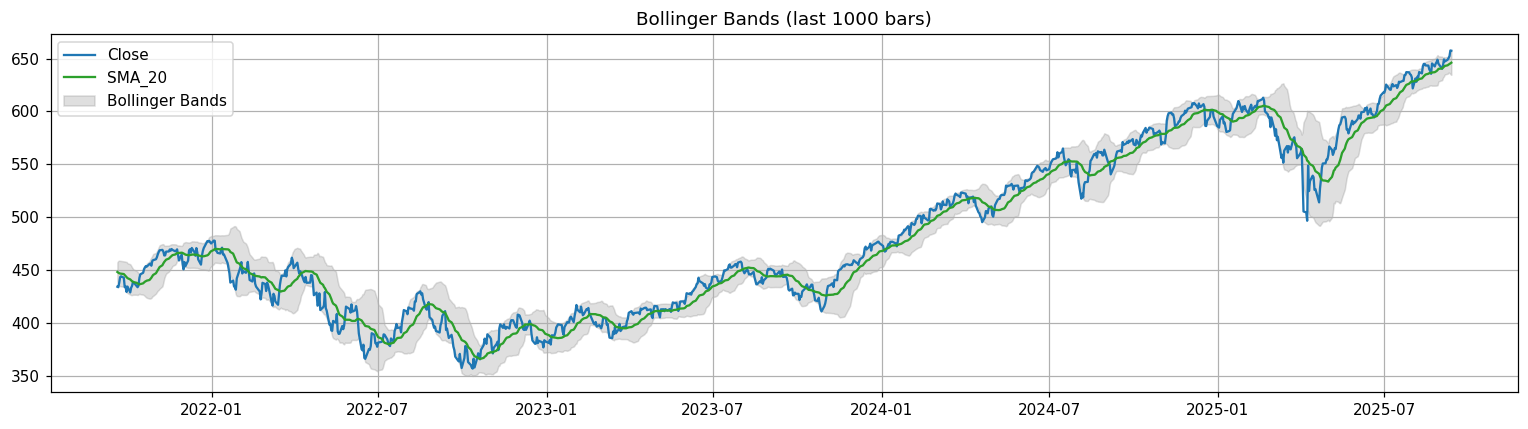

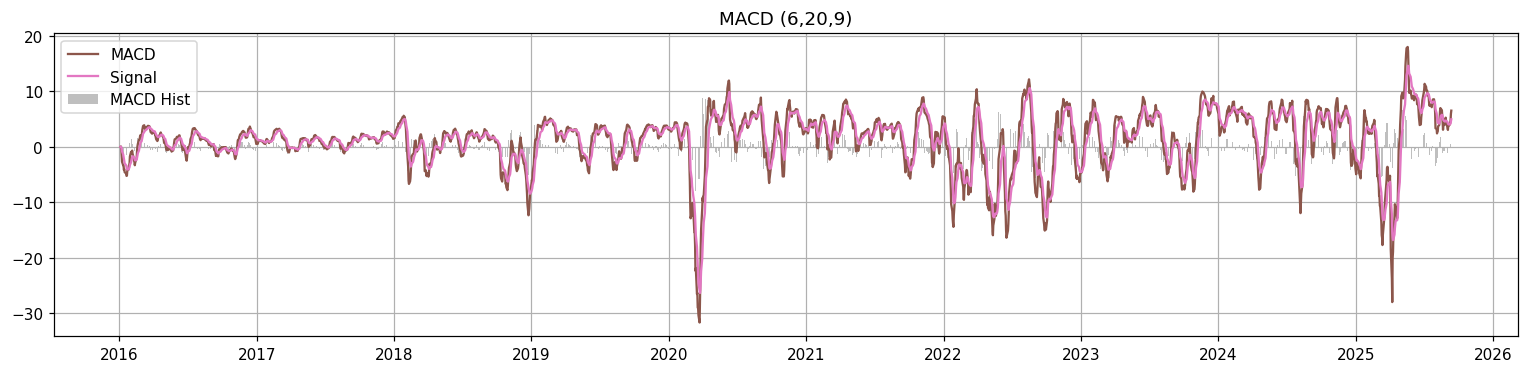

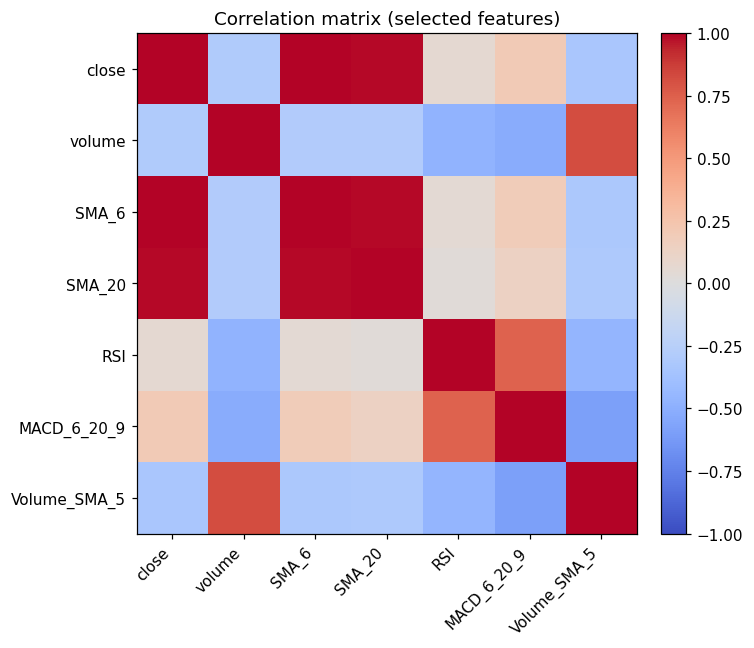

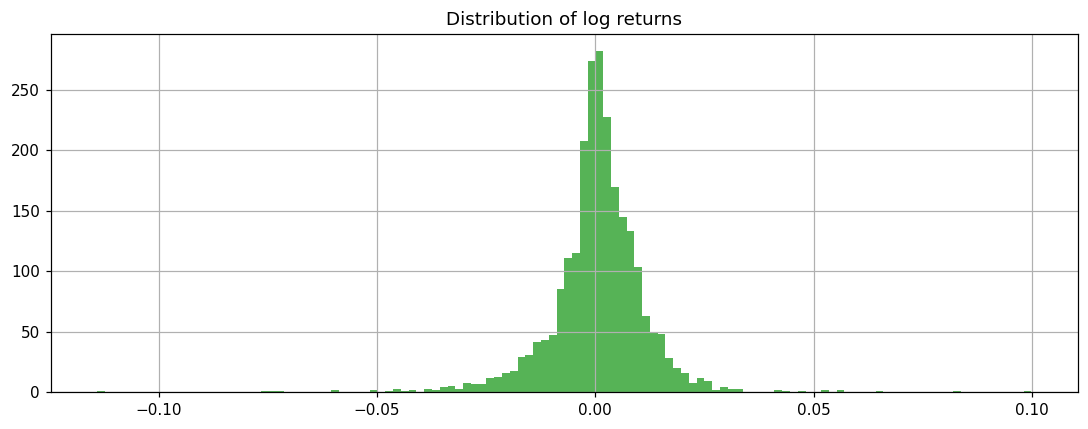

In [ ]:
# EDA cell (index 23)
# Uses existing variables/imports: stock_data, SYMBOL, pandas (pd), numpy (np), matplotlib.pyplot (plt)

df = stock_data.copy()

# Basic summaries
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nDescriptive statistics (selected columns):\n", df[['close', 'volume', 'SMA_6', 'SMA_20', 'RSI']].describe())

# Engineering simple EDA columns
df['log_return'] = np.log(df['close']).diff()

# Daily aggregations for plotting
daily_close = df['close'].resample('1D').last()
daily_volume = df['volume'].resample('1D').sum()

# Correlation for selected features
features = ['close', 'volume', 'SMA_6', 'SMA_20', 'RSI', 'MACD_6_20_9', 'Volume_SMA_5']
corr = df[features].corr()
print("\nCorrelation matrix (selected features):\n", corr)

# ---- Plots ----
plt.rcParams.update({'figure.dpi': 110})

# 1) Close price with SMAs, RSI and daily volume (stacked)
plt.figure(figsize=(14, 10))

ax1 = plt.subplot(3, 1, 1)
ax1.plot(df.index, df['close'], label='Close', color='C0', linewidth=0.6)
ax1.plot(df.index, df['SMA_6'], label='SMA_6', color='C1', linewidth=0.9)
ax1.plot(df.index, df['SMA_20'], label='SMA_20', color='C2', linewidth=0.9)
ax1.set_title(f"{SYMBOL} Close Price with SMA_6 and SMA_20")
ax1.legend(loc='best')
ax1.grid(True)

ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.plot(df.index, df['RSI'], color='C3', label='RSI')
ax2.axhline(70, color='red', linestyle='--', linewidth=0.7)
ax2.axhline(30, color='green', linestyle='--', linewidth=0.7)
ax2.set_title("RSI (14)")
ax2.legend(loc='best')
ax2.grid(True)

ax3 = plt.subplot(3, 1, 3, sharex=ax1)
ax3.bar(daily_volume.index, daily_volume.values, color='C4', width=0.8)
ax3.set_title("Daily Volume (resampled)")
ax3.grid(True)

plt.tight_layout()
plt.show()

# 2) Bollinger Bands zoom (last N bars)
window = 1000
sub = df[-window:]
plt.figure(figsize=(14, 4))
plt.plot(sub.index, sub['close'], label='Close', color='C0')
plt.plot(sub.index, sub['SMA_20'], label='SMA_20', color='C2')
plt.fill_between(sub.index, sub['Bollinger_Low'], sub['Bollinger_High'],
                 color='grey', alpha=0.25, label='Bollinger Bands')
plt.title(f"Bollinger Bands (last {min(window, len(df))} bars)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) MACD and histogram
plt.figure(figsize=(14, 3.5))
plt.plot(df.index, df['MACD_6_20_9'], label='MACD', color='C5')
plt.plot(df.index, df['MACD_SIGNAL_6_20_9'], label='Signal', color='C6')
plt.bar(df.index, df['MACD_HIST_6_20_9'], label='MACD Hist', color='gray', alpha=0.5)
plt.title("MACD (6,20,9)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Correlation heatmap (selected features) using matplotlib
plt.figure(figsize=(7, 6))
im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(features)), features, rotation=45, ha='right')
plt.yticks(range(len(features)), features)
plt.title("Correlation matrix (selected features)")
plt.tight_layout()
plt.show()

# 5) Distribution of log returns
plt.figure(figsize=(10, 4))
vals = df['log_return'].dropna()
plt.hist(vals, bins=120, color='C2', alpha=0.8)
plt.title("Distribution of log returns")
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Prepare the Data
</div>

1. Auxiliary Methods

In [ ]:
def load_and_preprocess_data(csv_path):
    """Load and preprocess the SPY bar data"""
    print("Loading and preprocessing data...")

    # Load the CSV data directly
    df = pd.read_csv(csv_path)

    # Convert trade_date to datetime
    df["trade_date"] = pd.to_datetime(df["trade_date"])

    # Convert trade_time to datetime.time objects consistently
    if "trade_time" in df.columns:
        if isinstance(df["trade_time"].iloc[0], str):
            # Convert string time to datetime.time objects
            df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time

    # Filter incomplete rows
    df = df[df["close"].notnull()].copy()

    # Sort by timestamp
    

    df = df.sort_values("timestamp")
    
    # Fill or drop missing values
    df["momentum_5"] = df["momentum_5"].fillna(0)
    df["momentum_10"] = df["momentum_10"].fillna(0)
    df["stddev_10"] = df["stddev_10"].bfill().fillna(0)
    df["relative_volume_30"] = df["relative_volume_30"].bfill().fillna(0)
    df["SMA_6"] = df["SMA_6"].bfill().fillna(0)
    df["SMA_20"] = df["SMA_20"].bfill().fillna(0)
    df["RSI"] = df["RSI"].bfill().fillna(0)
    df["MACD_6_20_9"] = df["MACD_6_20_9"].bfill().fillna(0)
    df["MACD_SIGNAL_6_20_9"] = df["MACD_SIGNAL_6_20_9"].bfill().fillna(0)
    df["MACD_HIST_6_20_9"] = df["MACD_HIST_6_20_9"].bfill().fillna(0)

    # Forward fill open_at_930am per day
    df["open_at_930am"] = df.groupby("trade_date")["open_at_930am"].transform(lambda x: x.ffill().bfill())

    # Fill minutes_since_open with -1 to indicate non-market hours
    df["minutes_since_open"] = df["minutes_since_open"].fillna(-1)

    print(f"Preprocessed data shape: {df.shape}")
    print(f"Date range: {df['trade_date'].min()} to {df['trade_date'].max()}")

    return df

2. Preprocess data

In [ ]:
stock_data_preprocessed = load_and_preprocess_data(csv_file_path)

Loading and preprocessing data...
Preprocessed data shape: (2438, 30)
Date range: 2016-01-04 00:00:00 to 2025-09-12 00:00:00


C:\Users\Afiat_Trading\AppData\Local\Temp\ipykernel_89240\3612006824.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time


In [ ]:
stock_data_preprocessed.head()

,timestamp,close,high,low,trade_count,open,volume,vwap,trade_date,trade_time,...,close_at_4pm,SMA_6,SMA_20,RSI,MACD_6_20_9,MACD_SIGNAL_6_20_9,MACD_HIST_6_20_9,Bollinger_High,Bollinger_Low,Volume_SMA_5
0,2016-01-04 05:00:00+00:00,201.0192,201.03,198.59,655489,200.490,225903783,199.753436,2016-01-04,05:00:00,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,2016-01-05 05:00:00+00:00,201.3600,201.90,200.05,418709,201.405,112719152,201.085380,2016-01-05,05:00:00,...,0.0,0.0,0.0,0.0,0.064914,0.012983,0.051931,0.0,0.0,0.0
2,2016-01-06 05:00:00+00:00,198.8200,200.06,197.60,548386,198.330,153948196,198.839872,2016-01-06,05:00:00,...,0.0,0.0,0.0,0.0,-0.378710,-0.065356,-0.313354,0.0,0.0,0.0
3,2016-01-07 05:00:00+00:00,194.0500,197.44,193.59,796451,195.330,216191953,195.202134,2016-01-07,05:00:00,...,0.0,0.0,0.0,0.0,-1.563673,-0.365019,-1.198654,0.0,0.0,0.0
4,2016-01-08 05:00:00+00:00,191.9230,195.85,191.58,754102,195.190,216105404,193.673322,2016-01-08,05:00:00,...,0.0,0.0,0.0,0.0,-2.692059,-0.830427,-1.861632,0.0,0.0,184973697.6


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Build the LSTM Model
</div>

1. Build LSTM Sequence

In [219]:
def build_lstm_sequences(df, features, lookback_days=60):
    """Build input sequences for the LSTM model"""
    print(f"\nBuilding LSTM sequences with {lookback_days} days lookback...")

    # Ensure trade_date is in datetime format
    df = df.copy()
    df["trade_date"] = pd.to_datetime(df["trade_date"])

    # Make sure trade_time is properly handled
    if "trade_time" in df.columns and len(df) > 0:
        if isinstance(df["trade_time"].iloc[0], str):
            try:
                df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time
            except Exception as e:
                print(f"Warning: Could not convert trade_time to datetime: {e}")
                # Create a fallback column
                df["time_for_comparison"] = df["trade_time"]

    # Print feature list with dtypes

    '''
    print("\nFeature list:")
    for feature in features:
        if feature in df.columns:
            print(f"  {feature}: {df[feature].dtype}")
        else:
            print(f"  {feature}: NOT FOUND")
    '''
            

    # Get unique dates sorted chronologically
    trade_dates = sorted(df["trade_date"].unique())
    print(f"Total trading days: {len(trade_dates)}")

    # Define sequence parameters
    expected_bars_per_day = 1
    current_day_bars_cutoff = 0
    sequence_length = lookback_days * expected_bars_per_day

    # Prepare containers for sequences
    X, y, date_labels = [], [], []

    # Loop through dates to build sequences
    sequences_built = 0
    sequences_skipped = 0

    for i in range(lookback_days, len(trade_dates)):
        past_dates = trade_dates[i - lookback_days:i]
        target_date = trade_dates[i]

        try:
            # Get past days' data
            past_data = df[df["trade_date"].isin(past_dates)]

            if len(past_data) == 0:
                print(f"No past data for dates {past_dates}")
                sequences_skipped += 1
                continue

            # Get current day's data up to cutoff time
            day_data = df[df["trade_date"] == target_date]

            if len(day_data) == 0:
                print(f"No data for target date {target_date}")
                sequences_skipped += 1
                continue

            # Combine past and current data
            sequence_df = pd.concat([past_data, day_data])

            # Check for missing features
            missing_features = [f for f in features if f not in sequence_df.columns]
            if missing_features:
                print(f"Missing features for date {target_date}: {missing_features}")
                sequences_skipped += 1
                continue

            # Extract feature values
            features_only = sequence_df[features].values

            # Handle sequence length (pad or truncate)
            if len(features_only) < sequence_length:
                pad_len = sequence_length - len(features_only)
                padded = np.pad(features_only, ((pad_len, 0), (0, 0)), mode="constant", constant_values=0)
            elif len(features_only) > sequence_length:
                padded = features_only[-sequence_length:]
            else:
                padded = features_only

            # Store the sequence
            X.append(padded)
            y.append(day_data["close"].values[-1])  # Target is the last close price of the target day
            date_labels.append(target_date)
            
            sequences_built += 1
            if sequences_built % 50 == 0:
                print(f"Built {sequences_built} sequences so far...")

            
        except Exception as e:
            print(f"Error building sequence for date {target_date}: {e}")
            import traceback
            traceback.print_exc()
            sequences_skipped += 1

    print(f"Sequences built: {sequences_built}, Sequences skipped: {sequences_skipped}")

    if sequences_built == 0:
        print("WARNING: No valid sequences could be built!")
        return np.array([]), np.array([]), [], np.array([])

    return np.array(X), np.array(y), date_labels


2. Select Features for the LSTM Model

In [220]:
print(stock_data_preprocessed.columns)

Index(['timestamp', 'close', 'high', 'low', 'trade_count', 'open', 'volume',
       'vwap', 'trade_date', 'trade_time', 'momentum_5', 'momentum_10',
       'stddev_10', 'relative_volume_30', 'minutes_since_open', 'bar_num',
       'high_since_open', 'low_since_open', 'cumulative_volume',
       'open_at_930am', 'close_at_4pm', 'SMA_6', 'SMA_20', 'RSI',
       'MACD_6_20_9', 'MACD_SIGNAL_6_20_9', 'MACD_HIST_6_20_9',
       'Bollinger_High', 'Bollinger_Low', 'Volume_SMA_5'],
      dtype='object')


3. Build the Sequence

In [221]:

features = [
    "open", "high", "low", "close", "volume",
    "momentum_5", "momentum_10", "stddev_10",
    "minutes_since_open", "vwap", "trade_count", 
    "relative_volume_30", 'high_since_open', 'low_since_open', 
    'cumulative_volume', 'open_at_930am', 'close_at_4pm', 
    'SMA_6', 'SMA_20', 'RSI', 'MACD_6_20_9', 
    'MACD_SIGNAL_6_20_9', 'MACD_HIST_6_20_9', 
    'Bollinger_High', 'Bollinger_Low', 'Volume_SMA_5' 
]

features = ["close"]

# Build sequences - with explicit debugging output
print("\nBuilding sequences with reference to time...")
X, y, date_labels = build_lstm_sequences(
    stock_data_preprocessed,
    features,
    lookback_days=7
)

print(f"\nFinal sequences shape: X={X.shape}, y={y.shape}, dates={len(date_labels)}")


Building sequences with reference to time...

Building LSTM sequences with 7 days lookback...
Total trading days: 2438
Built 50 sequences so far...
Built 100 sequences so far...
Built 150 sequences so far...
Built 200 sequences so far...
Built 250 sequences so far...
Built 300 sequences so far...
Built 350 sequences so far...
Built 400 sequences so far...
Built 450 sequences so far...
Built 500 sequences so far...
Built 550 sequences so far...
Built 600 sequences so far...
Built 650 sequences so far...
Built 700 sequences so far...
Built 750 sequences so far...
Built 800 sequences so far...
Built 850 sequences so far...
Built 900 sequences so far...
Built 950 sequences so far...
Built 1000 sequences so far...
Built 1050 sequences so far...
Built 1100 sequences so far...
Built 1150 sequences so far...
Built 1200 sequences so far...
Built 1250 sequences so far...
Built 1300 sequences so far...
Built 1350 sequences so far...
Built 1400 sequences so far...
Built 1450 sequences so far...
B

4. Split Dataset

In [222]:
# The following functions remain unchanged from your original code
def split_dataset(X, y, dates, train_ratio=0.7, val_ratio=0.15):
    """Split dataset into training, validation, and test sets"""
    if len(X) == 0:
        print("Cannot split an empty dataset!")
        return (np.array([]), np.array([]), np.array([]), [],
                np.array([]), np.array([]), [],
                np.array([]), np.array([]), [])

    print(f"\nSplitting dataset with {len(X)} sequences...")

    # Calculate split indices
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)

    # Split data chronologically
    X_train, y_train = X[:train_size], y[:train_size]
    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]
    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    # Split dates and noon prices
    train_dates = dates[:train_size]
    val_dates = dates[train_size:train_size+val_size]
    test_dates = dates[train_size+val_size:]

    print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

    if len(train_dates) > 0:
        print(f"Train dates: {train_dates[0]} to {train_dates[-1]}")
    if len(test_dates) > 0:
        print(f"Test dates: {test_dates[0]} to {test_dates[-1]}")

    return (X_train, y_train, train_dates,
            X_val, y_val, val_dates,
            X_test, y_test, test_dates)

In [223]:
# Split dataset - note the variable name change from noon_prices to reference_prices
print("\nSplitting dataset...")
(X_train, y_train, train_dates,
 X_val, y_val, val_dates,
 X_test, y_test, test_dates) = split_dataset(
    X, y, date_labels, train_ratio=0.7, val_ratio=0.15
)


Splitting dataset...

Splitting dataset with 2431 sequences...
Training set: (1701, 7, 1), Validation set: (364, 7, 1), Test set: (366, 7, 1)
Train dates: 2016-01-13 00:00:00 to 2022-10-13 00:00:00
Test dates: 2024-03-28 00:00:00 to 2025-09-12 00:00:00


5. Scale the Data

In [224]:

def scale_data(X_train, y_train, X_val, y_val, X_test, y_test):
    """Scale features and target values"""
    if len(X_train) == 0:
        print("Cannot scale empty datasets!")
        return None, None, np.array([]), np.array([]), np.array([]), np.array([])

    # Get dimensions from training data
    num_samples, timesteps, num_features = X_train.shape
    print(f"Scaling data with shape: {timesteps} timesteps, {num_features} features")
    print(f"Training samples: {num_samples}")

    # Reshape for scaling
    X_train_reshaped = X_train.reshape(-1, num_features)
    X_val_reshaped = X_val.reshape(-1, num_features) if len(X_val) > 0 else np.array([]).reshape(0, num_features)
    X_test_reshaped = X_test.reshape(-1, num_features) if len(X_test) > 0 else np.array([]).reshape(0, num_features)

    # Scale features
    feature_scaler = StandardScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)
    X_val_scaled = feature_scaler.transform(X_val_reshaped).reshape(X_val.shape) if len(X_val) > 0 else np.array([])
    X_test_scaled = feature_scaler.transform(X_test_reshaped).reshape(X_test.shape) if len(X_test) > 0 else np.array([])

    # Scale targets
    target_scaler = StandardScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).flatten() if len(y_val) > 0 else np.array([])
    y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten() if len(y_test) > 0 else np.array([])

    return feature_scaler, target_scaler, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled


In [225]:
print("\nScaling data...")
feature_scaler, target_scaler, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled = scale_data(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Scaling data...
Scaling data with shape: 7 timesteps, 1 features
Training samples: 1701


6. Create the LSTM Model

In [226]:

def create_lstm_model(input_shape):
    """Create and compile LSTM model"""
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)  # Output: price change from noon to close
    ])

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [227]:
# Create and train model
print("\nCreating and training model...")
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
model = create_lstm_model(input_shape)
model.summary()




Creating and training model...


c:\Users\Afiat_Trading\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Train the Model
</div>

1. Train the Model

In [228]:
def train_model(model, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, epochs=50, batch_size=32):
    """Train the LSTM model"""
    # Add callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.0001,
            verbose=1
        )
    ]

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    return model, history

In [229]:
model, history = train_model(
    model,
    X_train_scaled, y_train_scaled,
    X_val_scaled, y_val_scaled,
    epochs=50,
    batch_size=32
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1932 - mae: 0.2922 - val_loss: 0.1226 - val_mae: 0.2478 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0266 - mae: 0.1206 - val_loss: 0.0459 - val_mae: 0.1495 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0189 - mae: 0.1001 - val_loss: 0.0351 - val_mae: 0.1397 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0192 - mae: 0.1000 - val_loss: 0.0191 - val_mae: 0.0999 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0162 - mae: 0.0929 - val_loss: 0.0227 - val_mae: 0.1141 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0160 - mae: 0.0922 - val_loss: 0.0188 - val_mae: 0.1037 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0156 - mae: 0.0908 - val_loss: 0.0219 - val_mae: 0.1111 - learning_rate: 0.0010
Epoch 8/50
54/54 ━━━

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Performance Analysis
</div>

1. Plot Training History

In [230]:

def plot_training_history(history):
    """Plot training and validation loss/metrics"""
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # MAE plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()


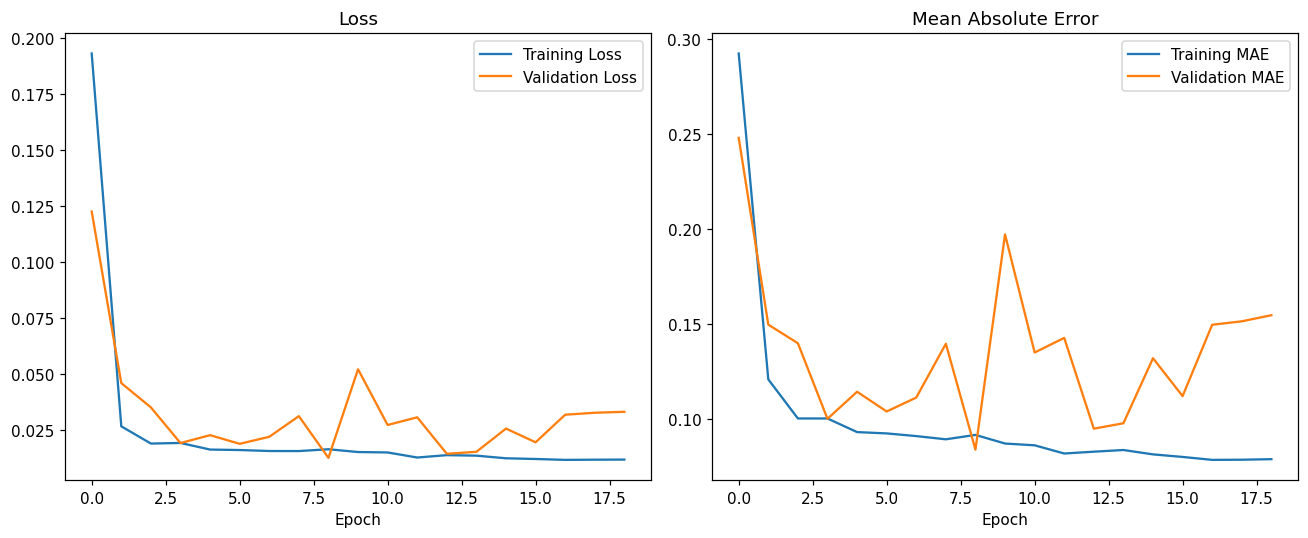

In [231]:
plot_training_history(history)

2. Evaluate the Model

In [232]:

def evaluate_model(model, target_scaler, X_test_scaled, y_test):
    """Evaluate model and return metrics and predictions"""
    # Make predictions
    y_pred_scaled = model.predict(X_test_scaled)

    # Inverse transform predictions
    y_pred_changes = target_scaler.inverse_transform(y_pred_scaled).flatten()

    # Calculate metrics for price changes
    mse_change = np.mean((y_test - y_pred_changes)**2)
    mae_change = np.mean(np.abs(y_test - y_pred_changes))
    rmse_change = np.sqrt(mse_change)

    # Calculate directional accuracy
    correct_direction = np.sum((y_test > 0) == (y_pred_changes > 0))
    direction_accuracy = correct_direction / len(y_test) * 100 if len(y_test) > 0 else 0

    # Print metrics
    print("\n=== Model Evaluation ===")
    print(f"Price Change Metrics:")
    print(f"  MSE: {mse_change:.4f}")
    print(f"  MAE: {mae_change:.4f}")
    print(f"  RMSE: {rmse_change:.4f}")

    print(f"\nMean Values:")
    print(f"  Mean Predicted Change: {np.mean(y_pred_changes):.4f}")
    print(f"  Mean Actual Change: {np.mean(y_test):.4f}")

    print(f"\nDirectional Accuracy: {direction_accuracy:.2f}%")

    return y_pred_changes, y_test


In [233]:
# Evaluate model - note the variable name change
y_pred_changes, y_test_changes = evaluate_model(
    model,
    target_scaler,
    X_test_scaled,
    y_test
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== Model Evaluation ===
Price Change Metrics:
  MSE: 3937.7446
  MAE: 57.2297
  RMSE: 62.7515

Mean Values:
  Mean Predicted Change: 517.6762
  Mean Actual Change: 574.8012

Directional Accuracy: 100.00%


3. Prediction

In [234]:

def plot_predictions(y_test, y_pred_changes, test_dates):
    """Plot predictions against actual values"""
    # Price change plot
    plt.figure(figsize=(14, 7))
    plt.plot(y_test, label="Actual Price Change", color='blue', alpha=0.7)
    plt.plot(y_pred_changes, label="Predicted Price Change", color='red', alpha=0.7)
    plt.title("SPY Price Change Prediction (Noon to 4pm)")
    plt.xlabel("Test Sample")
    plt.ylabel("Price Change")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



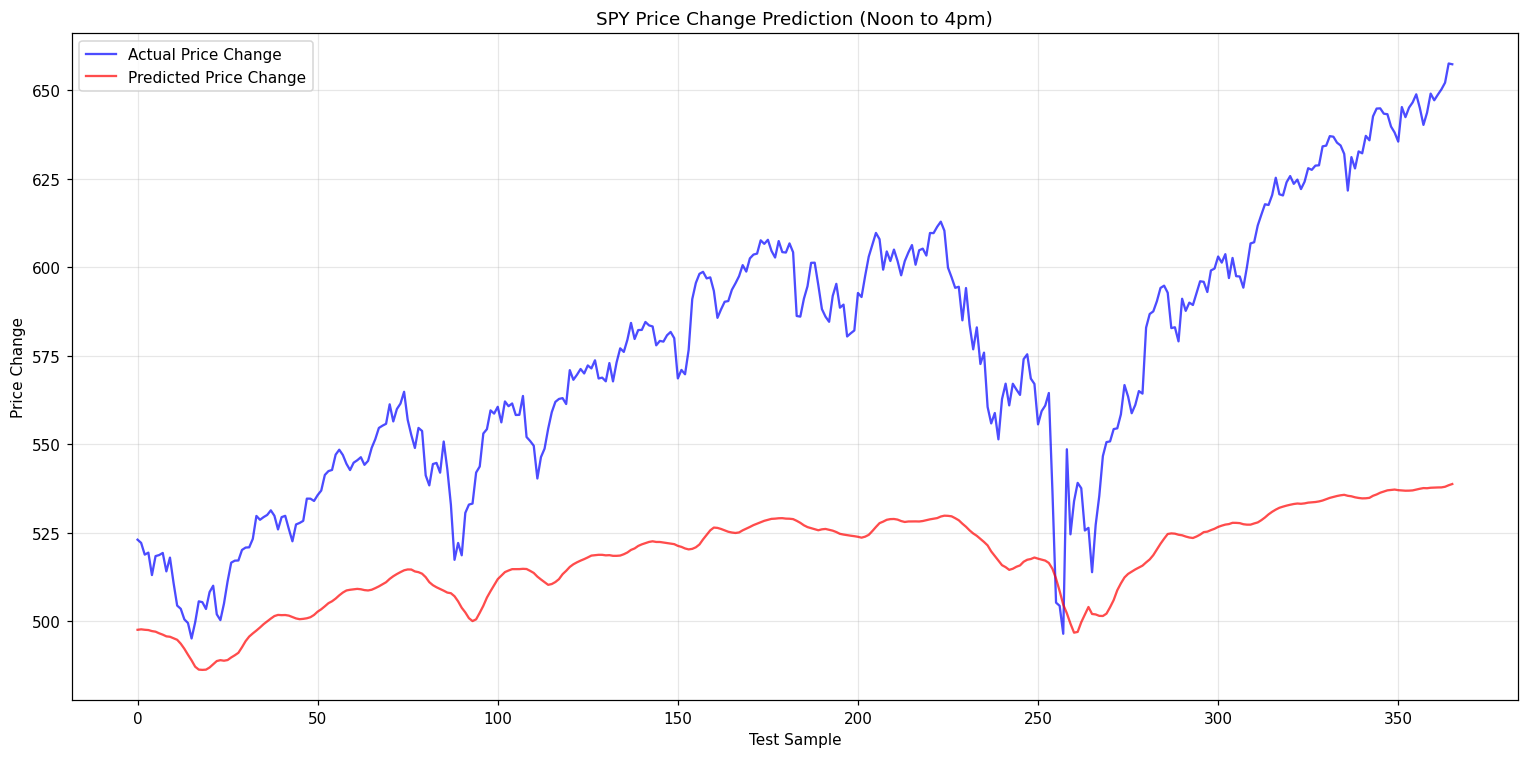

Model training and evaluation complete!


In [ ]:
# Plot predictions - note the variable name change
plot_predictions(
    y_test,
    y_pred_changes,
    test_dates
)

print("Model training and evaluation complete!")

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Prediction Results
</div>

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Future Prediction
</div>

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Conclusion
</div>

### Exploring something diferent

In [236]:
stock_data_preprocessed.head()

,timestamp,close,high,low,trade_count,open,volume,vwap,trade_date,trade_time,...,close_at_4pm,SMA_6,SMA_20,RSI,MACD_6_20_9,MACD_SIGNAL_6_20_9,MACD_HIST_6_20_9,Bollinger_High,Bollinger_Low,Volume_SMA_5
0,2016-01-04 05:00:00+00:00,201.0192,201.03,198.59,655489,200.490,225903783,199.753436,2016-01-04,05:00:00,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,2016-01-05 05:00:00+00:00,201.3600,201.90,200.05,418709,201.405,112719152,201.085380,2016-01-05,05:00:00,...,0.0,0.0,0.0,0.0,0.064914,0.012983,0.051931,0.0,0.0,0.0
2,2016-01-06 05:00:00+00:00,198.8200,200.06,197.60,548386,198.330,153948196,198.839872,2016-01-06,05:00:00,...,0.0,0.0,0.0,0.0,-0.378710,-0.065356,-0.313354,0.0,0.0,0.0
3,2016-01-07 05:00:00+00:00,194.0500,197.44,193.59,796451,195.330,216191953,195.202134,2016-01-07,05:00:00,...,0.0,0.0,0.0,0.0,-1.563673,-0.365019,-1.198654,0.0,0.0,0.0
4,2016-01-08 05:00:00+00:00,191.9230,195.85,191.58,754102,195.190,216105404,193.673322,2016-01-08,05:00:00,...,0.0,0.0,0.0,0.0,-2.692059,-0.830427,-1.861632,0.0,0.0,184973697.6


In [237]:
from datetime import date, timedelta

SYMBOL2 = 'SPY'  # Stock symbol to predict

try:
    api = tradeapi.REST(API_KEY, SECRET_KEY, BASE_URL, api_version='v2')

    # Fetch historical daily data for the specified stock symbol
    # We'll get a good amount of data to train the model effectively.
    # The limit is set to 1000, which is the maximum per request.
    start_date = date.today() - timedelta(days=10000)
    
    # Using api.get_bars and converting to a pandas DataFrame
    bars = api.get_bars(SYMBOL2, TimeFrame.Day, start=start_date.isoformat(), limit=10000).df
    
    # Ensure the 'close' price column is present and data is not empty
    if bars.empty:
        raise ValueError("No data returned from Alpaca API. Check your symbol or API keys.")
    
    # The 'close' column is automatically lowercase in the DataFrame
    df = pd.DataFrame(bars['close'])
    df.columns = ['Close']
    df.index = pd.to_datetime(df.index.date)
    
except Exception as e:
    print(f"Error fetching data from Alpaca API: {e}")
    print("Creating a dummy dataset for demonstration instead.")
    # Create a dummy dataset if API fails for demonstration purposes
    np.random.seed(42)
    dates = pd.date_range(start='2022-01-01', periods=365, freq='D')
    dummy_prices = 1500 + np.cumsum(np.random.randn(365) * 10) + np.sin(np.arange(365) / 30) * 100
    df = pd.DataFrame({'Close': dummy_prices}, index=dates)

In [238]:
df.head()

,Close
2016-01-04,201.0192
2016-01-05,201.3600
2016-01-06,198.8200
2016-01-07,194.0500
2016-01-08,191.9230


In [239]:
# Use the 'Close' price for prediction
data = df.filter(['Close']).values

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [240]:
scaled_data

array([[0.03776558],
       [0.03847434],
       [0.03319191],
       ...,
       [0.99059978],
       [0.99700524],
       [1.        ]], shape=(2443, 1))

In [241]:
# --- 2. Create Training Data ---
# Number of past days to use for prediction (the 'lookback' period)
lookback_period = 60
training_data_len = int(np.ceil(len(scaled_data) * 0.8))  # Use 80% for training

train_data = scaled_data[0:training_data_len, :]

# Split the data into x_train (features) and y_train (labels)
x_train = []
y_train = []

for i in range(lookback_period, len(train_data)):
    x_train.append(train_data[i - lookback_period:i, 0])
    y_train.append(train_data[i, 0])

# Convert x_train and y_train to numpy arrays for the LSTM model
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data for the LSTM model (3D: [samples, timesteps, features])
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [242]:
print("Scaled data shape:", scaled_data.shape)
print("Training data shape:", train_data.shape)
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

Scaled data shape: (2443, 1)
Training data shape: (1955, 1)
x_train shape: (1895, 60, 1)
y_train shape: (1895,)


In [243]:
# --- 3. Build the LSTM Model ---
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))         # input_shape=(timesteps, features)
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


c:\Users\Afiat_Trading\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [244]:
# --- 4. Train the Model ---
print("Training the LSTM model...")
model.fit(x_train, y_train, batch_size=32, epochs=50)

Training the LSTM model...
Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0097
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.2447e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.6675e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.0462e-04
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.9179e-04
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.7296e-04
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.1548e-04
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.7333e-04
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.9725e-04
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.3726e-04
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.8511e-04
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.0265e-04


In [245]:
print(scaled_data.shape)
print(lookback_period)

(2443, 1)
60


In [246]:
# --- 5. Make Predictions for the Future ---
# Create a new dataset containing the last 'lookback_period' days from the original data
last_lookback = scaled_data[-lookback_period:]                                                                  # get the last 'lookback_period' days
last_lookback = np.reshape(last_lookback, (1, last_lookback.shape[0], 1))

future_days = 30
predictions_30_days = []

current_input = last_lookback
for i in range(future_days):
    # Predict the next day's price
    predicted_price_scaled = model.predict(current_input, verbose=0)

    print(f"Day {i+1} predicted scaled price: {predicted_price_scaled[0, 0]:.6f}")

    predictions_30_days.append(predicted_price_scaled[0, 0])

    # Update the input sequence for the next prediction
    # Remove the first element and append the new prediction
    new_input = np.append(current_input[0, 1:, 0], predicted_price_scaled[0, 0])
    current_input = np.reshape(new_input, (1, new_input.shape[0], 1))

# Inverse transform the predictions to get the actual prices
predictions = scaler.inverse_transform(np.array(predictions_30_days).reshape(-1, 1))
future_dates = pd.date_range(start=df.index[-1], periods=future_days + 1, freq='D')[1:]

Day 1 predicted scaled price: 0.967437
Day 2 predicted scaled price: 0.962564
Day 3 predicted scaled price: 0.954634
Day 4 predicted scaled price: 0.945265
Day 5 predicted scaled price: 0.935268
Day 6 predicted scaled price: 0.925073
Day 7 predicted scaled price: 0.914927
Day 8 predicted scaled price: 0.904980
Day 9 predicted scaled price: 0.895324
Day 10 predicted scaled price: 0.886015
Day 11 predicted scaled price: 0.877084
Day 12 predicted scaled price: 0.868543
Day 13 predicted scaled price: 0.860388
Day 14 predicted scaled price: 0.852606
Day 15 predicted scaled price: 0.845178
Day 16 predicted scaled price: 0.838078
Day 17 predicted scaled price: 0.831281
Day 18 predicted scaled price: 0.824757
Day 19 predicted scaled price: 0.818481
Day 20 predicted scaled price: 0.812425
Day 21 predicted scaled price: 0.806566
Day 22 predicted scaled price: 0.800883
Day 23 predicted scaled price: 0.795357
Day 24 predicted scaled price: 0.789970
Day 25 predicted scaled price: 0.784709
Day 26 pr

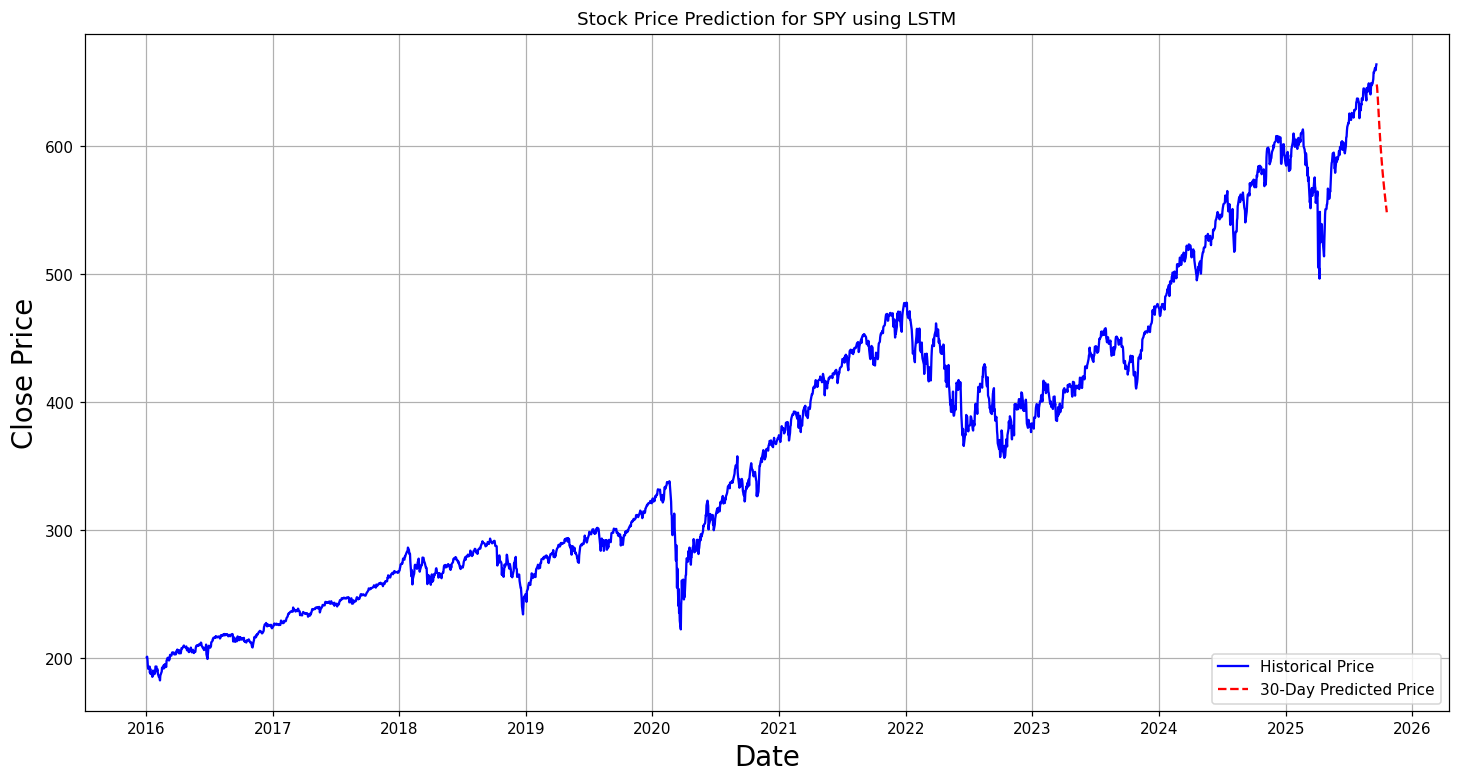

In [247]:
# --- 6. Visualize the Results ---
# Visualize the original data and the predicted future prices
plt.figure(figsize=(16, 8))
plt.title(f'Stock Price Prediction for {SYMBOL2} using LSTM')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)

# Plot historical data
plt.plot(df.index, data, label='Historical Price', color='blue')

# Plot predicted future prices
plt.plot(future_dates, predictions, label='30-Day Predicted Price', color='red', linestyle='--')

plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Training the LSTM model...
Epoch 1/50


c:\Users\Afiat_Trading\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0319
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0050
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0040
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0040
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0033
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0033
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0028
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0027
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0025
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0024
Epoch 13/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0027
Epoch 14/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0023
Epoch 15/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0025
Epoch 16/50
50/

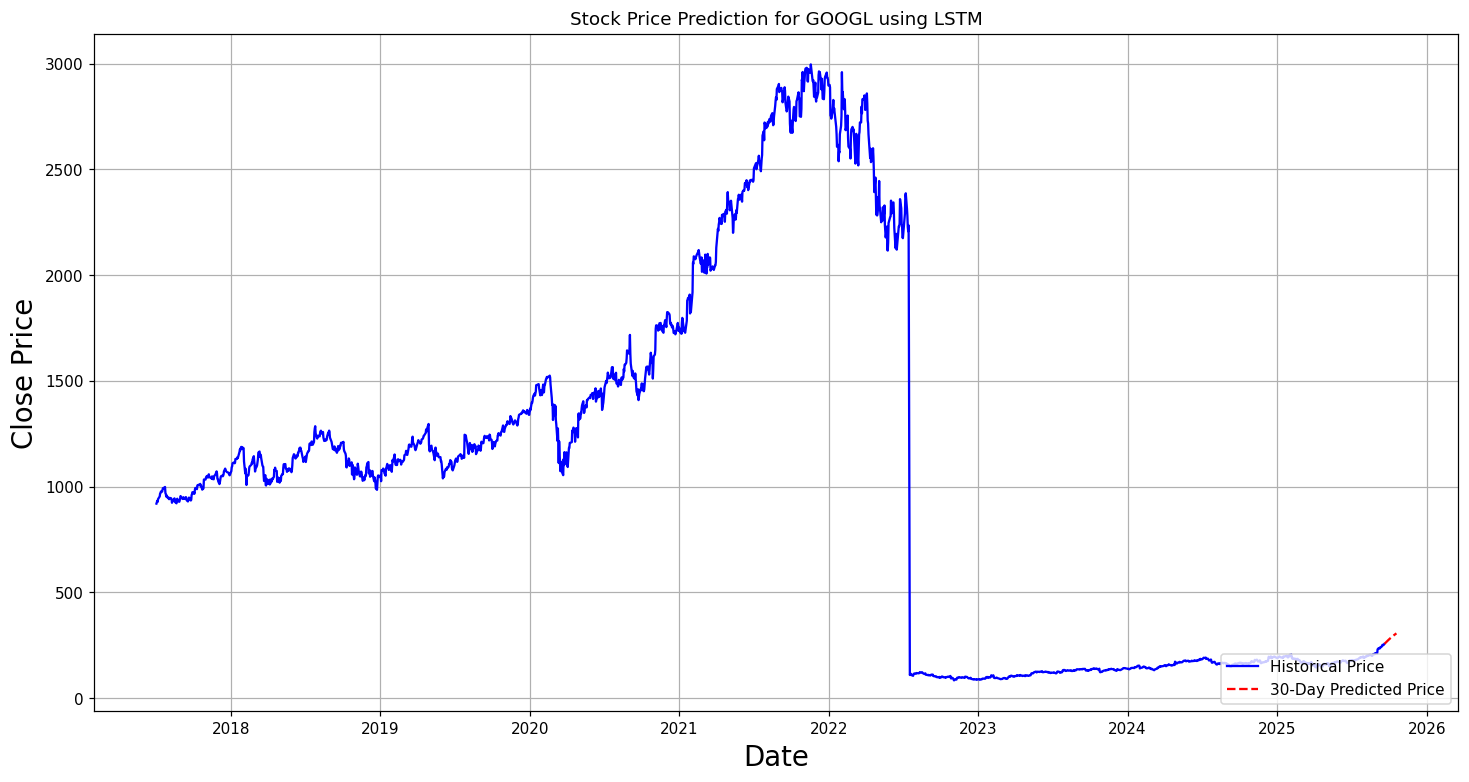

In [248]:
from datetime import date, timedelta

SYMBOL2 = 'GOOGL'  # Stock symbol to predict

try:
    api = tradeapi.REST(API_KEY, SECRET_KEY, BASE_URL, api_version='v2')

    # Fetch historical daily data for the specified stock symbol
    # We'll get a good amount of data to train the model effectively.
    # The limit is set to 1000, which is the maximum per request.
    start_date = date.today() - timedelta(days=3000)
    
    # Using api.get_bars and converting to a pandas DataFrame
    bars = api.get_bars(SYMBOL2, TimeFrame.Day, start=start_date.isoformat(), limit=3000).df
    
    # Ensure the 'close' price column is present and data is not empty
    if bars.empty:
        raise ValueError("No data returned from Alpaca API. Check your symbol or API keys.")
    
    # The 'close' column is automatically lowercase in the DataFrame
    df = pd.DataFrame(bars['close'])
    df.columns = ['Close']
    df.index = pd.to_datetime(df.index.date)
    
except Exception as e:
    print(f"Error fetching data from Alpaca API: {e}")
    print("Creating a dummy dataset for demonstration instead.")
    # Create a dummy dataset if API fails for demonstration purposes
    np.random.seed(42)
    dates = pd.date_range(start='2022-01-01', periods=365, freq='D')
    dummy_prices = 1500 + np.cumsum(np.random.randn(365) * 10) + np.sin(np.arange(365) / 30) * 100
    df = pd.DataFrame({'Close': dummy_prices}, index=dates)

# Use the 'Close' price for prediction
data = df.filter(['Close']).values

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# --- 2. Create Training Data ---
# Number of past days to use for prediction (the 'lookback' period)
lookback_period = 60
training_data_len = int(np.ceil(len(scaled_data) * 0.8))  # Use 80% for training

train_data = scaled_data[0:training_data_len, :]

# Split the data into x_train (features) and y_train (labels)
x_train = []
y_train = []

for i in range(lookback_period, len(train_data)):
    x_train.append(train_data[i - lookback_period:i, 0])
    y_train.append(train_data[i, 0])

# Convert x_train and y_train to numpy arrays for the LSTM model
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data for the LSTM model (3D: [samples, timesteps, features])
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# --- 3. Build the LSTM Model ---
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# --- 4. Train the Model ---
print("Training the LSTM model...")
model.fit(x_train, y_train, batch_size=32, epochs=50)

# --- 5. Make Predictions for the Future ---
# Create a new dataset containing the last 'lookback_period' days from the original data
last_lookback = scaled_data[-lookback_period:]
last_lookback = np.reshape(last_lookback, (1, last_lookback.shape[0], 1))

future_days = 30
predictions_30_days = []

current_input = last_lookback
for i in range(future_days):
    # Predict the next day's price
    predicted_price_scaled = model.predict(current_input, verbose=0)
    predictions_30_days.append(predicted_price_scaled[0, 0])

    # Update the input sequence for the next prediction
    # Remove the first element and append the new prediction
    new_input = np.append(current_input[0, 1:, 0], predicted_price_scaled[0, 0])
    current_input = np.reshape(new_input, (1, new_input.shape[0], 1))

# Inverse transform the predictions to get the actual prices
predictions = scaler.inverse_transform(np.array(predictions_30_days).reshape(-1, 1))
future_dates = pd.date_range(start=df.index[-1], periods=future_days + 1, freq='D')[1:]

# --- 6. Visualize the Results ---
# Visualize the original data and the predicted future prices
plt.figure(figsize=(16, 8))
plt.title(f'Stock Price Prediction for {SYMBOL2} using LSTM')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)

# Plot historical data
plt.plot(df.index, data, label='Historical Price', color='blue')

# Plot predicted future prices
plt.plot(future_dates, predictions, label='30-Day Predicted Price', color='red', linestyle='--')

plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Training the LSTM model...
Epoch 1/50


c:\Users\Afiat_Trading\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0340
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0063
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0042
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0030
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0028
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0030
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0026
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0026
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0023
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0025
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0020
Epoch 16/50
16/

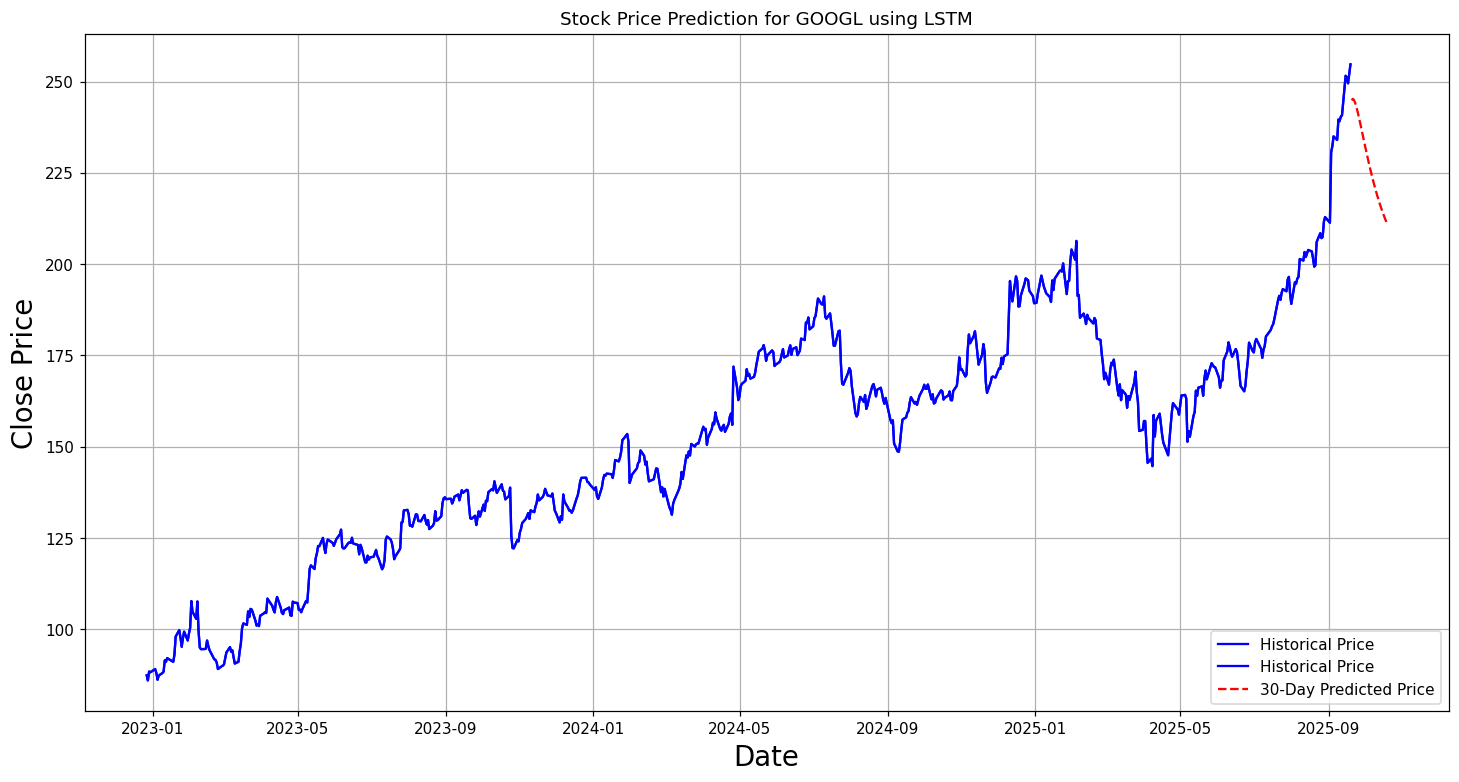

In [249]:
STOCK_SYMBOL = 'GOOGL'  # Stock symbol to predict


try:
    api = tradeapi.REST(API_KEY, SECRET_KEY, BASE_URL, api_version='v2')

# Fetch historical daily data for the specified stock symbol
    # We'll get a good amount of data to train the model effectively.
    # The limit is set to 1000, which is the maximum per request.
    start_date = date.today() - timedelta(days=1000)
    
    # Using api.get_bars and converting to a pandas DataFrame
    bars = api.get_bars(STOCK_SYMBOL, TimeFrame.Day, start=start_date.isoformat(), limit=1000).df
    
    # Ensure the 'close' price column is present and data is not empty
    if bars.empty:
        raise ValueError("No data returned from Alpaca API. Check your symbol or API keys.")
    
    # The 'close' column is automatically lowercase in the DataFrame
    df = pd.DataFrame(bars['close'])
    df.columns = ['Close']
    df.index = pd.to_datetime(df.index.date)
    
except Exception as e:
    print(f"Error fetching data from Alpaca API: {e}")
    print("Creating a dummy dataset for demonstration instead.")
    # Create a dummy dataset if API fails for demonstration purposes
    np.random.seed(42)
    dates = pd.date_range(start='2022-01-01', periods=365, freq='D')
    dummy_prices = 1500 + np.cumsum(np.random.randn(365) * 10) + np.sin(np.arange(365) / 30) * 100
    df = pd.DataFrame({'Close': dummy_prices}, index=dates)

# Use the 'Close' price for prediction
data = df.filter(['Close']).values

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
# 'stock_data' is not defined in this cell; use the prepared 'data' (2D array)
scaled_data = scaler.fit_transform(data)

# --- 2. Create Training Data ---
# Number of past days to use for prediction (the 'lookback' period)
lookback_period = 60
training_data_len = int(np.ceil(len(scaled_data) * 0.8))  # Use 80% for training

train_data = scaled_data[0:training_data_len, :]

# Split the data into x_train (features) and y_train (labels)
x_train = []
y_train = []

for i in range(lookback_period, len(train_data)):
    x_train.append(train_data[i - lookback_period:i, 0])
    y_train.append(train_data[i, 0])

# Convert x_train and y_train to numpy arrays for the LSTM model
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data for the LSTM model (3D: [samples, timesteps, features])
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# --- 3. Build the LSTM Model ---
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# --- 4. Train the Model ---
print("Training the LSTM model...")
model.fit(x_train, y_train, batch_size=32, epochs=50)

# --- 5. Make Predictions for the Future ---
# Create a new dataset containing the last 'lookback_period' days from the original data
last_lookback = scaled_data[-lookback_period:]
last_lookback = np.reshape(last_lookback, (1, last_lookback.shape[0], 1))

future_days = 30
predictions_30_days = []

current_input = last_lookback
for i in range(future_days):
    # Predict the next day's price
    predicted_price_scaled = model.predict(current_input, verbose=0)
    predictions_30_days.append(predicted_price_scaled[0, 0])

    # Update the input sequence for the next prediction
    # Remove the first element and append the new prediction
    new_input = np.append(current_input[0, 1:, 0], predicted_price_scaled[0, 0])
    current_input = np.reshape(new_input, (1, new_input.shape[0], 1))

# Inverse transform the predictions to get the actual prices
predictions = scaler.inverse_transform(np.array(predictions_30_days).reshape(-1, 1))
future_dates = pd.date_range(start=df.index[-1], periods=future_days + 1, freq='D')[1:]

# --- 6. Visualize the Results ---
# Create a DataFrame for plotting the predicted prices
predicted_df = pd.DataFrame(data=predictions, index=future_dates, columns=['Close'])

# Visualize the combined historical and predicted data
plt.figure(figsize=(16, 8))
plt.title(f'Stock Price Prediction for {STOCK_SYMBOL} using LSTM')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
# Plot historical data
# use the DataFrame series directly (1D) for plotting
plt.plot(df.index, df['Close'], label='Historical Price', color='blue')
plt.plot(df.index, data, label='Historical Price', color='blue')

# Plot the predicted data starting from the end of the historical data
plt.plot(predicted_df.index, predicted_df['Close'], label='30-Day Predicted Price', color='red', linestyle='--')

plt.legend(loc='lower right')
plt.grid(True)
plt.show()